<a href="https://colab.research.google.com/github/yuvanarvind/Duke-AI-XAI/blob/yuvan-work/final-project/Sleep_Analysis_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Analysis - Final Project

### -Yuvan

In [1]:
!pip install pandas numpy scikit-learn shap matplotlib

In [2]:
import os
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt
import joblib
pd.options.display.max_columns = 200


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset from Drive

In [4]:
DRIVE_BASE = "/content/drive/MyDrive/XAI"           # your XAI folder
INPUT_CSV = os.path.join(DRIVE_BASE, "ring_data_2025_46.csv")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "sleep_xai_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
import pandas as pd

file_path = '/content/drive/MyDrive/XAI/ring_data_2025_46.csv'

df = pd.read_csv(file_path)
df.head()


,timestamp_epoch,data_type,value
0,1762732922,raw_hr,91.0
1,1762733223,raw_hr,87.0
2,1762733522,raw_hr,86.0
3,1762733823,raw_hr,87.0
4,1762734122,raw_hr,87.0


In [11]:
df.info()
df.describe(include='all')
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9328 entries, 0 to 9327
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp_epoch  9328 non-null   int64  
 1   data_type        9328 non-null   object 
 2   value            9328 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 218.8+ KB


Index(['timestamp_epoch', 'data_type', 'value'], dtype='object')

Pivot from long → wide format

In [12]:
# Pivot long → wide
df_wide = df.pivot(index="timestamp_epoch", columns="data_type", values="value").reset_index()

# Convert epoch to datetime
df_wide["timestamp"] = pd.to_datetime(df_wide["timestamp_epoch"], unit="s")

# Sort
df_wide = df_wide.sort_values("timestamp").reset_index(drop=True)

df_wide.head()


data_type,timestamp_epoch,raw_hr,raw_hrv_2,raw_motion,respiratory_rate,spo2,steps,temp,timestamp
0,1762732922,91.0,59.0,NaN,NaN,99.0,NaN,NaN,2025-11-10 00:02:02
1,1762733069,NaN,NaN,11.0,7.0,NaN,0.0,34.523438,2025-11-10 00:04:29
2,1762733223,87.0,84.0,NaN,NaN,99.0,NaN,NaN,2025-11-10 00:07:03
3,1762733369,NaN,NaN,0.0,11.0,NaN,0.0,34.156250,2025-11-10 00:09:29
4,1762733522,86.0,52.0,NaN,NaN,98.0,NaN,NaN,2025-11-10 00:12:02


Sort & Resample to 1-minute intervals

In [13]:
# Use timestamp as index
df_wide = df_wide.set_index("timestamp")

# Resample to 1-minute intervals (fill missing values with forward-fill)
df_resampled = df_wide.resample("1T").mean().ffill().bfill()

df_resampled.head()


/tmp/ipython-input-1766371025.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_wide.resample("1T").mean().ffill().bfill()


data_type,timestamp_epoch,raw_hr,raw_hrv_2,raw_motion,respiratory_rate,spo2,steps,temp
timestamp,,,,,,,,
2025-11-10 00:02:00,1.762733e+09,91.0,59.0,11.0,7.0,99.0,0.0,34.523438
2025-11-10 00:03:00,1.762733e+09,91.0,59.0,11.0,7.0,99.0,0.0,34.523438
2025-11-10 00:04:00,1.762733e+09,91.0,59.0,11.0,7.0,99.0,0.0,34.523438
2025-11-10 00:05:00,1.762733e+09,91.0,59.0,11.0,7.0,99.0,0.0,34.523438
2025-11-10 00:06:00,1.762733e+09,91.0,59.0,11.0,7.0,99.0,0.0,34.523438


In [14]:
# Rolling features (5-minute window)
df_resampled["hr_rolling"]   = df_resampled["raw_hr"].rolling(5).mean()
df_resampled["hrv_rolling"]  = df_resampled["raw_hrv_2"].rolling(5).mean()
df_resampled["motion_roll"]  = df_resampled["raw_motion"].rolling(5).mean()
df_resampled["temp_roll"]    = df_resampled["temp"].rolling(5).mean()
df_resampled["rr_roll"]      = df_resampled["respiratory_rate"].rolling(5).mean()


In [15]:
df_resampled["stillness_index"] = 1 / (1 + df_resampled["raw_motion"])


In [16]:
df_resampled["slowing_score"] = (
    (df_resampled["hr_rolling"].max() - df_resampled["hr_rolling"]) +
    (df_resampled["hrv_rolling"] - df_resampled["hrv_rolling"].min())
)


In [17]:
df_resampled["awake_flag"] = (df_resampled["steps"] > 0).astype(int)


In [18]:
df_resampled.tail()


data_type,timestamp_epoch,raw_hr,raw_hrv_2,raw_motion,respiratory_rate,spo2,steps,temp,hr_rolling,hrv_rolling,motion_roll,temp_roll,rr_roll,stillness_index,slowing_score,awake_flag
timestamp,,,,,,,,,,,,,,,,
2025-11-14 18:26:00,1.763145e+09,72.0,237.0,150.0,0.0,97.0,33.0,25.148438,72.0,237.0,150.0,24.848437,0.0,0.006623,312.0,1
2025-11-14 18:27:00,1.763145e+09,69.0,225.0,150.0,0.0,97.0,33.0,25.148438,71.4,234.6,150.0,24.948438,0.0,0.006623,310.2,1
2025-11-14 18:28:00,1.763145e+09,69.0,225.0,150.0,0.0,97.0,33.0,25.148438,70.8,232.2,150.0,25.048437,0.0,0.006623,308.4,1
2025-11-14 18:29:00,1.763145e+09,69.0,225.0,150.0,0.0,97.0,33.0,25.148438,70.2,229.8,150.0,25.148438,0.0,0.006623,306.6,1
2025-11-14 18:30:00,1.763145e+09,69.0,225.0,150.0,0.0,97.0,0.0,25.570312,69.6,227.4,150.0,25.232813,0.0,0.006623,304.8,0


## Sleep Score Formula
Normalize features (Z-score)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = [
    "hr_rolling", "hrv_rolling", "motion_roll",
    "rr_roll", "temp_roll"
]

df_scaled = df_resampled.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])


Build a weighted sleep score

In [20]:
df_scaled["sleep_score_raw"] = (
    (-df_scaled["hr_rolling"] * 0.20) +
    ( df_scaled["hrv_rolling"] * 0.25) +
    (-df_scaled["motion_roll"] * 0.25) +
    (-df_scaled["rr_roll"] * 0.15) +
    (-df_scaled["temp_roll"] * 0.15)
)


Convert to a clean 0–100 scale

In [21]:
# Min-max scale to 0–100
score_min = df_scaled["sleep_score_raw"].min()
score_max = df_scaled["sleep_score_raw"].max()

df_scaled["sleep_score"] = (
    (df_scaled["sleep_score_raw"] - score_min) /
    (score_max - score_min)
) * 100


Check sleep_score

In [22]:
df_scaled[["sleep_score"]].describe()


data_type,sleep_score
count,6865.000000
mean,49.098240
std,16.002494
min,0.000000
25%,38.563271
50%,49.528071
75%,59.538373
max,100.000000


Select Features & Prepare Train/Test Data

In [23]:
# Step 6A: Select features and target
feature_cols = ["hr_rolling", "hrv_rolling", "motion_roll", "rr_roll", "temp_roll"]
target_col = "sleep_score"

X = df_scaled[feature_cols]
y = df_scaled[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.shape, y.shape


((6869, 5), (6869,))

Train a Simple, Interpretable Model

In [25]:
#Train a Random Forest model
# Drop rows where sleep_score is NaN
df_model = df_scaled.dropna(subset=["sleep_score"])

# Then drop/fill remaining NaNs in features
df_model = df_model.fillna(method="ffill").fillna(method="bfill")

# Redefine X and y cleanly
X = df_model[feature_cols]
y = df_model[target_col]

# Train/test split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.shape, y.shape



/tmp/ipython-input-3623917973.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model = df_model.fillna(method="ffill").fillna(method="bfill")


((6865, 5), (6865,))

In [27]:
# Step 6B: Train a Random Forest model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("Sleep Model trained!")


Sleep Model trained!


Evaluate the Model (RMSE + R²)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# RMSE (manual)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


Model Performance:
RMSE: 4.904
R²:   0.909


Generate SHAP values

In [31]:
#Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values computed!")


SHAP values computed!


SHAP Summary Plot

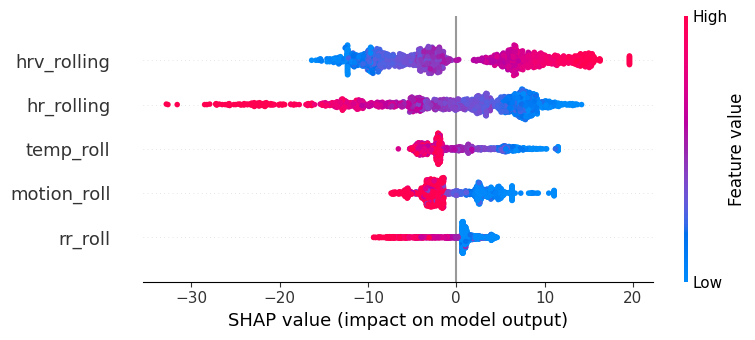

In [32]:
shap.summary_plot(shap_values, X_test)


Pick one sample from the test set to explain


In [34]:
i = 10   # you can change this to any index

x_single = X_test.iloc[[i]]
shap_single = explainer.shap_values(x_single)[0]


Convert SHAP values into confidence percentages


In [35]:

feature_names = X_test.columns.tolist()
shap_abs = np.abs(shap_single)

# Normalize to percentages
confidence_scores = shap_abs / shap_abs.sum() * 100

# Create a readable table
explanation_df = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_single,
    "confidence_percent": confidence_scores
}).sort_values("confidence_percent", ascending=False)

explanation_df


,feature,shap_value,confidence_percent
0,hr_rolling,-16.047877,42.741443
1,hrv_rolling,-14.344988,38.206019
4,temp_roll,-3.629422,9.666497
2,motion_roll,-2.656490,7.075216
3,rr_roll,0.867632,2.310825


Final Human interpretable text

In [36]:
#Build a natural language explanation

# Get predicted sleep score for this sample
predicted_score = model.predict(x_single)[0]

explanation_lines = []
for idx, row in explanation_df.iterrows():
    feature = row["feature"]
    direction = "increased" if row["shap_value"] > 0 else "decreased"
    percent = round(row["confidence_percent"], 1)

    explanation_lines.append(
        f"- {percent}% confidence: {feature} {direction} your sleep score"
    )

final_explanation = (
    f"Predicted Sleep Score for this night: {predicted_score:.1f}/100\n\n"
    "What affected your sleep the most:\n" +
    "\n".join(explanation_lines)
)

print(final_explanation)


Predicted Sleep Score for this night: 13.5/100

What affected your sleep the most:
- 42.7% confidence: hr_rolling decreased your sleep score
- 38.2% confidence: hrv_rolling decreased your sleep score
- 9.7% confidence: temp_roll decreased your sleep score
- 7.1% confidence: motion_roll decreased your sleep score
- 2.3% confidence: rr_roll increased your sleep score
